# 19 · The Halo driver: `examples/halo_sizing.py` from top to bottom

Everything so far was preparation for this file. `examples/halo_sizing.py` (about 1,950 lines) is the Halo-class aircraft: its requirements, its
roughly 150 documented assumptions and model switches, the function that builds the aircraft from a design, the one coupled sizing problem, the
result, the starting-point strategy, and the named assumption sets that keep every earlier reference reproducible. It has the structure of
tutorial 18's coupled sizing, with every model at higher fidelity and more flight points.

**In this notebook**
1. A map of the file.
2. `HaloRequirements`, `HaloAssumptions`, `HaloDesign`: inputs, switches and the design vector.
3. `build_halo_aircraft`: from a design (numbers or variables) to an `Aircraft`.
4. `solve_halo_sizing_once`: the problem, section by section.
5. Solving the current reference (with the fast Scholz aerodynamics) and reading the result.
6. The named assumption sets and how to switch models.

**Run time:** about 2 minutes the first time (one near-reference sizing, then cached in `tutorials/.cache/`), seconds afterwards.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect, re
from dataclasses import fields, replace
import examples.halo_sizing as hs
from examples.halo_sizing import (HaloRequirements, HaloAssumptions, HaloDesign, HaloSizingResult, build_halo_aircraft,
                                  build_halo_aerodynamics, solve_halo_sizing, solve_halo_sizing_once)
source_file = inspect.getsource(hs)

## 1. A map of the file

In [2]:
for match in re.finditer(r"^(def|class) (\w+)|^# ---- (.+?) -+$|^([a-z_0-9]+) = ", source_file, flags=re.M):
    line = source_file.count("\n", 0, match.start()) + 1
    if match.group(3):
        print(f"{line:5d}  ---- {match.group(3)}")
    elif match.group(2):
        print(f"{line:5d}  {match.group(1)} {match.group(2)}")
    elif match.group(4) and line < 130 or (match.group(4) and match.group(4).startswith(("assumptions_", "requirements_", "pre_"))):
        print(f"{line:5d}      {match.group(4)} = ...")

   88      fuel_factor = ...
   89      soc_take_off = ...
   90      soc_minimum = ...
   91      soc_emergency_floor = ...
   92      scale_objective_cost_usd = ...
   96  class EquipmentItem
  104      xv15_equipment_items = ...
  112      uncrewed_equipment_adjustments = ...
  124      halo_equipment_items = ...
  127  def mass_equipment_from_items_kg
  132  class HaloRequirements
  173  class HaloAssumptions
  428  class HaloDesign
  458  def battery_thermal
  467  def build_halo_battery
  487  class BusVoltageWindow
  495  def bus_voltage_window
  507  def power_electric_rated_W
  512  def build_halo_electrical
  568  def count_lanes_motor
  573  def build_halo_redundancy
  606  def build_halo_aerodynamics
  624  def ratio_reference_gear_stages
  630  def stage_mass_ratio
  635  def build_halo_aircraft
  901  def halo_mission
  917  class HaloSizingResult
  975  def count_parallel_guess
  987  def unit_machine
  996  def machine_units_record
 1006  def solve_halo_sizing
 1075  de

Reading order: `HaloRequirements` → `HaloAssumptions` → `HaloDesign` → `build_halo_aircraft` (and its helpers `build_halo_battery`,
`build_halo_electrical`, `build_halo_redundancy`, `build_halo_aerodynamics`) → `halo_mission` → `solve_halo_sizing` (the public entry point: integer
units, gear-stage fallback, starting points) → `solve_halo_sizing_once` (the one coupled problem) → summaries → the starting-point strategy
(tutorial 20) → named assumption sets → studies (`solve_halo_max_payload`, `enumerate_bus_voltage`).

## 2. Inputs, switches and the design vector

`HaloRequirements` (tutorial 16) says what the aircraft must do. `HaloAssumptions` holds every engineering assumption and every model switch, each
commented with its source, and grouped by the tier or plan that introduced it. Count them by group:

In [3]:
assumption_source = inspect.getsource(HaloAssumptions)
headers = [(m.start(), m.group(1).strip()) for m in re.finditer(r"#\s*----\s*(.+?)\s*-*\s*$", assumption_source, flags=re.M)]
groups = {}
for f in fields(HaloAssumptions):
    position = re.search(rf"^\s+{f.name}:", assumption_source, flags=re.M).start()
    group = next((name for start, name in reversed(headers) if start < position), "Tiers 10-13 (base)")
    groups.setdefault(group, []).append(f.name)
for group, names in groups.items():
    print(f"{len(names):3d}  {group}")
print(f"{sum(len(v) for v in groups.values()):3d}  fields in total")
check("every assumption field is counted once", sum(len(v) for v in groups.values()) == len(fields(HaloAssumptions)))

 38  Tiers 10-13 (base)
  9  Tier 17 battery (plan 021)
 16  Tier 15 electrical layer (plan 023)
 21  Tier 20 wing weight (plan 024)
  5  Tier 21 aerodynamics (plan 025)
 13  Tier 22 design-space practice (plan 029)
  1  Fuselage mass (plan 037)
 12  Tier 19 thermal (plan 028)
 10  Tier 18 redundancy (plan 032)
  7  Plan 033 machine database and gearbox stages (refines Tier 13)
 11  Plan 035: machines from whole units of real best-in-class products ("no rubber motors", author 2026-10-04)
143  fields in total
PASS  every assumption field is counted once


The **model switches** are the fields that select a model rather than set a number. Each one keeps the simpler model available (rule 10):

In [4]:
a = HaloAssumptions()
switches = ["aerodynamics_model", "battery_model", "wing_weight_model", "machine_mass_model", "rotor_speed_physics", "thermal_model",
            "redundancy", "electrical_layer", "gearbox_stages", "drag_corrections", "temperature_lapse", "machine_mass_by_torque",
            "generator_step_up", "integer_units", "turbogenerators_on_wing_tips", "free_altitude_cruise", "free_aspect_ratio_wing",
            "free_soc_reserve", "hover_hot_day"]
for name in switches:
    holder = a if hasattr(a, name) else HaloRequirements()
    print(f"{name:<30} {getattr(holder, name)!r}")

aerodynamics_model             'buildup'
battery_model                  'ecm'
wing_weight_model              'afdd_tiltrotor'
machine_mass_model             'units'
rotor_speed_physics            True
thermal_model                  True
redundancy                     True
electrical_layer               False
gearbox_stages                 True
drag_corrections               True
temperature_lapse              True
machine_mass_by_torque         True
generator_step_up              True
integer_units                  True
turbogenerators_on_wing_tips   False
free_altitude_cruise           False
free_aspect_ratio_wing         False
free_soc_reserve               False
hover_hot_day                  True


`HaloDesign` is the design vector: every sized quantity, each field a number or an Opti variable. Optional fields are `None` when the corresponding
model is off (e.g. `count_parallel_battery` only with the equivalent-circuit pack; `speed_tip_m_s` and `solidity` only with the rotor-speed physics):

In [5]:
print(inspect.getsource(HaloDesign))

@dataclass(frozen=True)
class HaloDesign:
    """Every sized quantity; fields may be Opti variables or numbers."""
    x_le_wing_m: Any
    area_wing_m2: Any
    area_horizontal_tail_m2: Any
    area_vertical_tail_m2: Any
    torque_peak_motor_Nm: Any
    torque_peak_generator_Nm: Any
    power_rated_turboshaft_W: Any
    mass_turboshaft_bare_kg: Any
    power_max_discharge_battery_W: Any
    energy_capacity_battery_J: Any
    area_disk_m2: Any
    mass_fuel_kg: Any
    solidity: Any = None                          # None: the assumption value (fixed)
    speed_tip_m_s: Any = None                     # design (hover) tip speed; None: the assumption value
    speed_peak_motor_rad_s: Any = None            # Tier 13 variables; None: the assumption values
    reduction_ratio: Any = None
    speed_peak_generator_rad_s: Any = None
    count_parallel_battery: Any = None            # Tier 17 "ecm": parallel strings (continuous); energy and power
                                                

## 3. `build_halo_aircraft(design, requirements, assumptions)`

One function turns a design into an `Aircraft` (tutorial 12), whether the design holds numbers (analysis, plotting, checks) or variables (sizing).
Its sections, in order:

1. **Machines** (tutorial 05): rubber McDonald machines placed by the peak-point variables, mass by torque/database/units, thermal models;
   `unit_machine` for whole units.
2. **Rotor and drive** (06, 08): AFDD rotor group × calibration; gearbox from AFDD × stage mass factor; step-up gearbox per engine;
   `MomentumProfileRotor` (or the actuator disk).
3. **Battery** (07) via `build_halo_battery`; **turboshaft** (06) with the regression mass and efficiency, the XV-15 lapse and the deck cubic.
4. **Electrical layer** (09) and **redundancy** (11) via their builders; then `build_series_hybrid` (11).
5. **Airframe** (12): nacelles, the wing (AFDD tiltrotor with tip masses and pylon inertia, or Raymer), tails, the layout fuselage, gear,
   systems, equipment items, payload and fuel; the `PowertrainInstallation` with every instance's position; `InstalledCooling`.

Build it from a solved design (tutorial 00's fast set) and look at what came out:

In [6]:
from examples.halo_sizing import requirements_tier16, assumptions_tier16
fast = solve_halo_sizing(requirements_tier16, assumptions_tier16)
aircraft = build_halo_aircraft(fast.design, requirements_tier16, assumptions_tier16)
from aircraft_closure.vehicle.condition import StructuralDesignCondition
breakdown = aircraft.get_mass_breakdown(StructuralDesignCondition(mass_design_kg=fast.mass_takeoff_kg,
                                                                  load_factor_ultimate=assumptions_tier16.load_factor_ultimate))
for f in fields(breakdown):
    print(f"{f.name:<16}{getattr(breakdown, f.name).mass:8.0f} kg")
print(f"{'total':<16}{breakdown.total().mass:8.0f} kg  (MTOM {fast.mass_takeoff_kg:,.0f} kg; the structural condition differs slightly from the "
      f"sizing's, which also feeds cruise speed and L/D)")

wing                 448 kg
horizontal_tail       28 kg
vertical_tail         20 kg
fuselage             561 kg
landing_gear         240 kg
systems              454 kg
powertrain          2015 kg
payload              900 kg
fuel                1034 kg
nacelles             195 kg
drive_shaft            0 kg
equipment            266 kg
total               6162 kg  (MTOM 6,242 kg; the structural condition differs slightly from the sizing's, which also feeds cruise speed and L/D)


## 4. `solve_halo_sizing_once`: the problem

The function is long but linear. Its sections, with the source of each printed below:

| Section | Content |
|---|---|
| Design variables | `HaloDesign` built from Opti variables with bounds and scales; optional variables appear only with their models |
| Mission | `halo_mission` with cruise and loiter speed variables |
| Aircraft, mission, requirements | `build_halo_aircraft(design, ...)`; `build_mission(...)` (SOC floor at every segment, sub-segments, thermal history); one point per capability requirement |
| Reserves and failures | engine-out hover (3 sub-points from the reserve SOC, polarization developed, thermal history from the take-off hover); hot-day hover at end-of-mission mass and SOC; failure hovers (lane, bus, string out) |
| Mass closure | the structural condition fed by the solved cruise speed and L/D |
| Stability, geometry, stall | static margin, Cn_beta, SOC end, SOC after engine-out, stall lift at 120 kt, rotor radius ≤ span clearance |
| Whirl flutter | at every airplane-mode point, the wing's torsion and beam frequencies per rev of that point's rotor speed ≥ the XV-15 placement |
| Constraints | closure, hover trim, fuel = 1.1 × burnt, engine regression; every margin ≥ 0 |
| Cost and objective | cost per mission (`mission/cost.py`); minimize MTOM, maximize payload, or minimize cost |
| Result | every expression converted with `solution.value` into `HaloSizingResult` |

In [7]:
once = inspect.getsource(solve_halo_sizing_once)
start, end = once.find("    design = HaloDesign("), once.find("    if a.machine_mass_by_torque:")
print(once[start:end])

    design = HaloDesign(
        x_le_wing_m=opti.variable(init_guess=guess.x_le_wing_m, lower_bound=3.0, upper_bound=8.5),
        area_wing_m2=opti.variable(init_guess=guess.area_wing_m2, scale=10.0, lower_bound=5.0, upper_bound=60.0),
        area_horizontal_tail_m2=opti.variable(init_guess=guess.area_horizontal_tail_m2, lower_bound=0.5),
        area_vertical_tail_m2=opti.variable(init_guess=guess.area_vertical_tail_m2, lower_bound=0.5),
        torque_peak_motor_Nm=opti.variable(init_guess=guess.torque_peak_motor_Nm, scale=1000.0, lower_bound=100.0),
        torque_peak_generator_Nm=opti.variable(init_guess=guess.torque_peak_generator_Nm, scale=1000.0,
                                               lower_bound=100.0),
        # Tier 19: the cooler's rating and the drive's own rating (the motor's becomes continuous).
        power_rated_heat_exchanger_W=opti.variable(
            init_guess=guess.power_rated_heat_exchanger_W if guess.power_rated_heat_exchanger_W is not None
       

In [8]:
start, end = once.find("    design_margins = ("), once.find("    all_margins = (")
print(once[start:end])
start, end = once.find("    opti.subject_to([\n        mass_takeoff_kg / total.mass == 1"), once.find("    # ---- Cost per mission")
print(once[start:end])

    design_margins = (
        margin_above("static_margin", static_margin, 0.10),
        margin_above("cn_beta_per_rad", cn_beta_per_rad, 0.06),
        margin_above("soc_end", flown.soc_end, soc_reserve),
        margin_above("soc_after_engine_out_hover", soc_after_reserve, soc_emergency_floor),
        margin_above("stall_lift_at_120kt", lift_stall_N, weight_N),
        margin_below("rotor_radius_m", radius_m, (span_m - a.diameter_fuselage_m) / 2 - a.clearance_rotor_fuselage_m),
    )

    opti.subject_to([
        mass_takeoff_kg / total.mass == 1,                                           # mass closure
        x_cg_m == aircraft.wing.x_le_root_m + 0.25 * aircraft.wing.chord_root_m(),   # hover pitch trim
        design.mass_fuel_kg == fuel_factor * flown.mass_fuel_burnt_kg,               # fuel with reserve
        power_turboshaft(design.mass_turboshaft_bare_kg) / design.power_rated_turboshaft_W == 1,  # engine regression
    ])
    opti.subject_to([m.value >= 0 for m in all_ma

Notice three things that recur in every model of the repository:

- every **failure** is one more flight point (or short mission) in the same problem, sharing every component and design variable;
- every **limit** is a named margin, collected into one list and constrained with one line;
- the only conversion to numbers is in the result constructor at the end.

## 5. Solving the current reference

The full reference (AeroBuildup aerodynamics) takes 10-15 minutes because of its starting-point ladder. With `aerodynamics_model="scholz"` (tutorial
13's hand check) and every other model at the reference setting (equivalent-circuit pack, AFDD wing, thermal, redundancy, units, gear stages,
JVX rotor), it solves in about a minute and lands within 0.3 % of the reference's 15,179 lb. It is cached, so tutorial 20 reuses it.

In [9]:
assumptions = replace(HaloAssumptions(), aerodynamics_model="scholz")
requirements = HaloRequirements()
reference = cached("reference_scholz", lambda: solve_halo_sizing(requirements, assumptions))
print(f"take-off {lb(reference.mass_takeoff_kg):,.0f} lb ({reference.mass_takeoff_kg:,.0f} kg); empty {lb(reference.mass_empty_kg):,.0f} lb; "
      f"fuel {lb(reference.mass_fuel_kg):,.0f} lb; payload {reference.mass_payload_kg:.0f} kg")
print(f"machine units (relaxed count, whole count): {reference.machine_units}")
print("start record:", reference.start.label if reference.start else "none: this is the integer-unit re-solve, warm-started from the relaxed-unit solve (tutorial 20)")
check("the Scholz near-reference is within 1 % of the 15,179 lb reference", abs(lb(reference.mass_takeoff_kg) / 15179 - 1) < 0.01)

take-off 15,134 lb (6,865 kg); empty 11,087 lb; fuel 2,063 lb; payload 900 kg
machine units (relaxed count, whole count): {'motor': (2.0, 2), 'generator': (3.0, 3)}
start record: none: this is the integer-unit re-solve, warm-started from the relaxed-unit solve (tutorial 20)
PASS  the Scholz near-reference is within 1 % of the 15,179 lb reference


### What sizes it

In [10]:
for label in reference.binding:
    print("  ", label)

   rotor_radius_m
   engine-out hover 3/3: battery end voltage_V
   hot-day hover: heat_exchanger power_heat_W
   engine-out hover 3/3: turboshaft power_shaft_W
   engine-out hover 3/3: generator_gearbox power_input_W
   hover: gearbox power_input_W
   hover: propulsor power_shaft_W
   engine-out hover 1/3: turboshaft power_shaft_W
   engine-out hover 1/3: generator_gearbox power_input_W
   hot-day hover: turboshaft power_shaft_W
   engine-out hover 2/3: turboshaft power_shaft_W
   engine-out hover 2/3: generator_gearbox power_input_W
   static_margin
   cn_beta_per_rad
   bus-out hover 1/3: motor torque_Nm
   engine-out hover 3/3: generator torque_Nm
   engine-out hover 1/3: generator torque_Nm
   engine-out hover 2/3: generator torque_Nm


### The result object

`HaloSizingResult` holds scalars, the numeric design (`reference.design`, a `HaloDesign` of floats, ready to rebuild the aircraft), and traces. A few:

In [11]:
print("fields:", ", ".join(f.name for f in fields(HaloSizingResult)))
print()
d = reference.design
print(f"wing {d.area_wing_m2:.1f} m2 (span {reference.span_m:.2f} m), rotors R {reference.radius_rotor_m:.2f} m, solidity {d.solidity:.3f}, "
      f"tip speed {d.speed_tip_m_s:.0f} m/s, gear ratio {d.reduction_ratio:.2f}, battery {d.count_parallel_battery:.1f} strings "
      f"({reference.energy_battery_kWh:.0f} kWh)")
print(f"cruise {reference.velocity_cruise_m_s / u.knot:.0f} kt at L/D {reference.lift_to_drag_cruise:.1f}; SOC end {reference.soc_end:.3f}, "
      f"after engine-out {reference.soc_after_engine_out:.3f}")
print(f"cost per mission ${reference.cost.per_mission_usd:,.0f} (acquisition ${reference.cost.acquisition_usd / 1e6:.1f} M)")
print("\nfailure hovers:")
for case in reference.failure_cases:
    print(f"   {case['label']:<20} SOC end {case['soc_end']:.3f}, lane torque/max {case['torque_lane_to_max']:.2f}, "
          f"motor end {case['temperature_end_motor_C']:.0f} C, binding {case['binding']}")

fields: mass_takeoff_kg, mass_payload_kg, mass_empty_kg, mass_fuel_kg, mass_fuel_burnt_kg, design, energy_battery_kWh, radius_rotor_m, span_m, disk_loading_kg_m2, wing_loading_kg_m2, power_rated_motor_W, power_rated_generator_W, velocity_cruise_m_s, velocity_loiter_m_s, lift_to_drag_cruise, cl_cruise, static_margin, cn_beta_per_rad, soc_end, soc_after_engine_out, closure_residual_kg, turboshaft_mass_power_residual, thermal_efficiency_turboshaft, segments, binding, min_margin, component_masses_kg, powertrain_masses_kg, hovers, soc_after_hover_hot, battery_trace, engine_out_trace, wing_masses_kg, whirl_flutter, start, cost, machine_units, thermal_trace, heat_exchanger, count_lanes_motor, failure_cases

wing 23.2 m2 (span 11.93 m), rotors R 4.83 m, solidity 0.060, tip speed 238 m/s, gear ratio 4.51, battery 22.8 strings (70 kWh)
cruise 161 kt at L/D 9.1; SOC end 0.433, after engine-out 0.106
cost per mission $3,342 (acquisition $6.8 M)

failure hovers:
   bus-out hover        SOC end 0.20

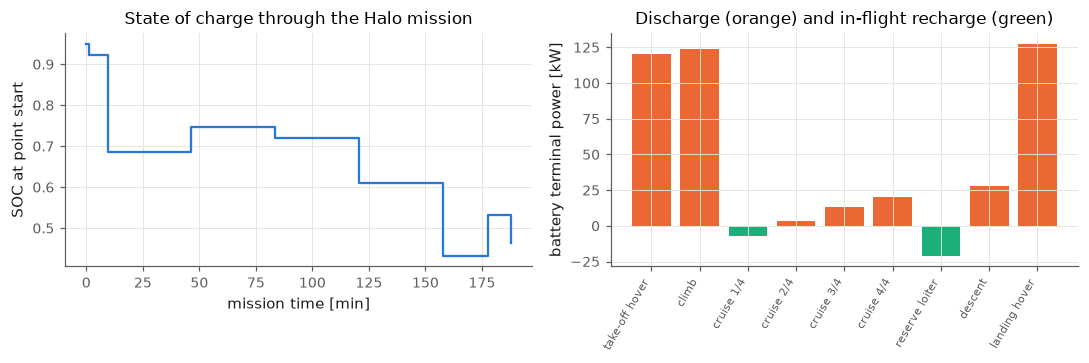

engine-out hover, 3 sub-points:
   engine-out hover 1/3     SOC 0.300 -> 0.239, end voltage 606.8 V (cutoff 525 V), 984 A
   engine-out hover 2/3     SOC 0.239 -> 0.175, end voltage 579.9 V (cutoff 525 V), 1023 A
   engine-out hover 3/3     SOC 0.175 -> 0.106, end voltage 525.0 V (cutoff 525 V), 1115 A
PASS  the pack ends the engine-out hover on its cell cutoff (voltage sizes the battery)


In [12]:
trace = reference.battery_trace
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
t_min = onp.array([row["time_start_s"] for row in trace]) / 60
axes[0].step(t_min, [row["soc_start"] for row in trace], where="post", color=blue)
axes[0].set(xlabel="mission time [min]", ylabel="SOC at point start", title="State of charge through the Halo mission")
axes[1].bar(range(len(trace)), [row["power_W"] / 1e3 for row in trace], color=[orange if row["power_W"] > 0 else aqua for row in trace])
axes[1].set(xticks=range(len(trace)), ylabel="battery terminal power [kW]", title="Discharge (orange) and in-flight recharge (green)")
axes[1].set_xticklabels([row["label"] for row in trace], rotation=60, ha="right", fontsize=7)
plt.tight_layout(); plt.show()
eo = reference.engine_out_trace
print("engine-out hover, 3 sub-points:")
for row in eo:
    print(f"   {row['label']:<24} SOC {row['soc_start']:.3f} -> {row['soc_end']:.3f}, end voltage {row['voltage_end_V']:.1f} V "
          f"(cutoff {210 * 2.5:.0f} V), {row['current_A']:.0f} A")
check("the pack ends the engine-out hover on its cell cutoff (voltage sizes the battery)",
      abs(min(row["voltage_end_V"] for row in eo) - 525.0) < 0.5)

## 6. Named assumption sets: every earlier reference stays reproducible

At the bottom of the file, each earlier reference design is a named `HaloAssumptions(...)`/`HaloRequirements(...)` pair, built from the current
defaults with the later changes switched back (`pre_plan035`, `pre_layout`). `docs/AIRCRAFT_VERSIONS.md` maps them to aircraft versions.

In [13]:
for name in sorted(n for n in dir(hs) if n.startswith(("assumptions_", "requirements_")) and not callable(getattr(hs, n))):
    print(f"   {name}")
print("\npre_plan035 =", hs.pre_plan035)
print("pre_layout keys =", list(hs.pre_layout))

   assumptions_plan022


   assumptions_plan026
   assumptions_plan027
   assumptions_plan030
   assumptions_plan037
   assumptions_plan038
   assumptions_tier11a
   assumptions_tier12
   assumptions_tier12b
   assumptions_tier15
   assumptions_tier16
   assumptions_tier17
   assumptions_tier18
   assumptions_tier20
   requirements_plan022
   requirements_plan026
   requirements_plan027
   requirements_plan030
   requirements_plan037
   requirements_plan038
   requirements_tier10c
   requirements_tier12b
   requirements_tier16

pre_plan035 = {'drag_corrections': False, 'redundancy': False, 'machine_mass_model': 'torque_density', 'gearbox_stages': False}
pre_layout keys = ['mass_factor_fuselage', 'turbogenerators_on_wing_tips', 'height_fuselage_m', 'length_fuselage_m', 'x_horizontal_tail_m', 'ratio_radius_gyration_pylon', 'ratio_depth_spar_cap', 'thickness_min_torque_box_m', 'offset_x_turbogenerators_m', 'z_turbogenerators_m']


Switching a model is one `replace`. For example, the reference with the constant battery, or without redundancy:
```python
solve_halo_sizing(HaloRequirements(), replace(HaloAssumptions(), battery_model="constant"))
solve_halo_sizing(HaloRequirements(), replace(HaloAssumptions(), redundancy=False))
```
Tutorial 20 runs such studies, warm-started from this reference.

## Summary

- The driver is a single file: requirements, documented assumptions and switches, a design vector, an aircraft builder, one coupled problem, a
  result, a starting-point strategy, and reproducible named sets.
- `build_halo_aircraft` works on numbers or variables; the sizing calls it with variables, analyses with the solved design.
- The problem is tutorial 18's, at higher fidelity: more requirement points, a sub-segmented ECM mission, engine-out, hot-day and failure hovers,
  whirl-flutter margins, cost, three objectives.
- The result carries the numeric design and traces for the battery, the engine-out hover, failure cases, thermal state and cost.

## Check yourself

<details><summary>1. Where would you add a new requirement, say a 30 s hover at 6,000 ft at end-of-mission mass?</summary>

In `solve_halo_sizing_once`, next to the hot-day hover: one `build_flight_point` (or a one-segment `build_mission` for the SOC accounting) with the condition and `flown.mass_end_kg`; append its margins to `all_margins`; add a field to `HaloRequirements` to switch and parameterize it; report it in the result.
</details>

<details><summary>2. Why are the engines' power a fixed number while their mass is a variable?</summary>

The engines are bought (2 × 1,120 hp, a user decision: a non-OEM cannot add power), so power is an input. Mass and efficiency come from AeroSandbox regressions of power, inverted by the equality `power_turboshaft(mass) / power == 1` inside the problem (tutorial 06).
</details>

In [14]:
check_summary()

3 of 3 checks passed
